In [2]:
import os
import json
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else []

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import transformers
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

import albumentations as A
from sklearn.metrics import confusion_matrix

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIG_PATHS = {
    "split_csv": "/kaggle/input/notebooks/sumaiyahoque/nb-0-eda-and-data-prep/split.csv",  
    "results_json": "/kaggle/working/results.json",
    "checkpoint_dir": "/kaggle/working/",
}
os.makedirs(CONFIG_PATHS["checkpoint_dir"], exist_ok=True)

torch: 2.10.0+cu128
transformers: 5.0.0
CUDA available: True


In [3]:
df = pd.read_csv(CONFIG_PATHS["split_csv"])
print(df["split"].value_counts())
assert set(df["split"].unique()) == {"train", "val", "test"}

MASK_THRESHOLD = 127
IMG_SIZE = 512
NUM_CLASSES = 2

split
train    1035
val       318
test      168
Name: count, dtype: int64


In [5]:
CHECKPOINT = "nvidia/segformer-b0-finetuned-ade-512-512"

processor = SegformerImageProcessor.from_pretrained(CHECKPOINT)
IMG_MEAN = np.array(processor.image_mean)
IMG_STD = np.array(processor.image_std)
print("Processor mean/std:", IMG_MEAN, IMG_STD)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Processor mean/std: [0.485 0.456 0.406] [0.229 0.224 0.225]


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [6]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.2),
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

class SegDataset(Dataset):
    def __init__(self, dataframe, transform=None, mask_threshold=MASK_THRESHOLD):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mask_threshold = mask_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask >= self.mask_threshold).astype(np.uint8)

        if mask.shape[:2] != img.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]),
                               interpolation=cv2.INTER_NEAREST)

        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = img.astype(np.float32) / 255.0
        img = (img - IMG_MEAN) / IMG_STD          
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask).long()

        return img, mask, row["img_path"]

train_ds = SegDataset(df[df["split"] == "train"], transform=train_transform)
val_ds   = SegDataset(df[df["split"] == "val"],   transform=val_test_transform)
test_ds  = SegDataset(df[df["split"] == "test"],  transform=val_test_transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1035 | Val: 318 | Test: 168


In [7]:
model = SegformerForSemanticSegmentation.from_pretrained(
    CHECKPOINT,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True,   
)
model = model.to(DEVICE)

print("Re-initialized layer:", model.decode_head.classifier)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Re-initialized layer: Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))


In [8]:
FG_PCT = 0.08   
BG_PCT = 1 - FG_PCT
class_weights = torch.tensor([1.0 / BG_PCT, 1.0 / FG_PCT], dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

TRAIN_CONFIG = {
    "model": f"SegFormer-B0 ({CHECKPOINT})",
    "num_classes": NUM_CLASSES,
    "input_size": IMG_SIZE,
    "batch_size": 8,
    "epochs": 50,
    "optimizer": "AdamW",
    "learning_rate": 6e-5,             
    "weight_decay": 1e-4,
    "lr_schedule": "CosineAnnealingLR (T_max=epochs) with 5-epoch linear warmup",
    "loss_function": "Weighted CrossEntropyLoss (+ Dice loss, 0.5 weight each) -- computed manually, NOT the HF built-in loss",
    "class_weights": class_weights.tolist(),
    "seed": SEED,
}
print(json.dumps(TRAIN_CONFIG, indent=2))

train_loader = DataLoader(train_ds, batch_size=TRAIN_CONFIG["batch_size"], shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=TRAIN_CONFIG["batch_size"], shuffle=False,
                         num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=TRAIN_CONFIG["batch_size"], shuffle=False,
                          num_workers=2, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CONFIG["learning_rate"],
                               weight_decay=TRAIN_CONFIG["weight_decay"])

WARMUP_EPOCHS = 5
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, TRAIN_CONFIG["epochs"] - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)


def dice_loss_fn(logits, targets, eps=1e-6):
    probs = F.softmax(logits, dim=1)[:, 1]
    targets_f = targets.float()
    intersection = (probs * targets_f).sum(dim=(1, 2))
    union = probs.sum(dim=(1, 2)) + targets_f.sum(dim=(1, 2))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def forward_upsampled(model, imgs):
    outputs = model(pixel_values=imgs)
    logits = F.interpolate(outputs.logits, size=(IMG_SIZE, IMG_SIZE),
                            mode="bilinear", align_corners=False)
    return logits


def compute_loss(logits, masks):
    ce = ce_loss_fn(logits, masks)
    dice = dice_loss_fn(logits, masks)
    return 0.5 * ce + 0.5 * dice

{
  "model": "SegFormer-B0 (nvidia/segformer-b0-finetuned-ade-512-512)",
  "num_classes": 2,
  "input_size": 512,
  "batch_size": 8,
  "epochs": 50,
  "optimizer": "AdamW",
  "learning_rate": 6e-05,
  "weight_decay": 0.0001,
  "lr_schedule": "CosineAnnealingLR (T_max=epochs) with 5-epoch linear warmup",
  "loss_function": "Weighted CrossEntropyLoss (+ Dice loss, 0.5 weight each) -- computed manually, NOT the HF built-in loss",
  "class_weights": [
    0.1599999964237213,
    1.840000033378601
  ],
  "seed": 42
}


In [10]:
def compute_miou(preds, targets, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        pred_c = (preds == c)
        target_c = (targets == c)
        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        if union == 0:
            continue
        ious.append(intersection / union)
    return float(np.mean(ious)) if ious else 0.0


@torch.no_grad()
def evaluate(loader, model):
    model.eval()
    total_loss, total_miou, n_batches = 0.0, 0.0, 0
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = forward_upsampled(model, imgs)
        loss = ce_loss_fn(logits, masks)
        preds = logits.argmax(dim=1)
        total_loss += loss.item()
        total_miou += compute_miou(preds, masks)
        n_batches += 1
    return total_loss / n_batches, total_miou / n_batches

In [11]:
history = {"train_loss": [], "val_loss": [], "val_miou": []}
best_val_miou = -1.0
best_epoch = -1
start_time = time.time()

for epoch in range(1, TRAIN_CONFIG["epochs"] + 1):
    model.train()
    running_loss = 0.0
    for imgs, masks, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{TRAIN_CONFIG['epochs']}", leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        logits = forward_upsampled(model, imgs)
        loss = compute_loss(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    val_loss, val_miou = evaluate(val_loader, model)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_mIoU={val_miou:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        best_epoch = epoch
        torch.save(model.state_dict(),
                    os.path.join(CONFIG_PATHS["checkpoint_dir"], "segformer_best.pt"))

Epoch 1/50:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7640 | val_loss=0.4355 | val_mIoU=0.5338 | lr=2.40e-05


Epoch 2/50:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.6640 | val_loss=0.2664 | val_mIoU=0.5890 | lr=3.60e-05


Epoch 3/50:   0%|          | 0/129 [00:00<?, ?it/s]

...

Epoch 48 | train_loss=0.2177 | val_loss=0.0709 | val_mIoU=0.7474 | lr=2.92e-07


Epoch 49/50:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 49 | train_loss=0.2154 | val_loss=0.0704 | val_mIoU=0.7468 | lr=7.31e-08


Epoch 50/50:   0%|          | 0/129 [00:00<?, ?it/s]

Epoch 50 | train_loss=0.2141 | val_loss=0.0702 | val_mIoU=0.7471 | lr=0.00e+00



Training complete in 58.3 min. Best val mIoU = 0.7543 at epoch 19.


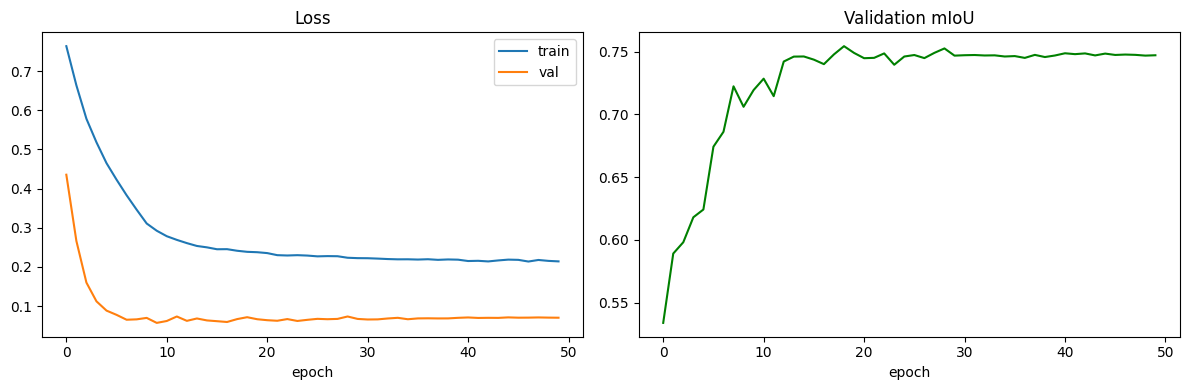

<All keys matched successfully>

In [12]:
total_train_time = time.time() - start_time
print(f"\nTraining complete in {total_train_time/60:.1f} min. "
      f"Best val mIoU = {best_val_miou:.4f} at epoch {best_epoch}.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_miou"], color="green")
axes[1].set_title("Validation mIoU"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

model.load_state_dict(torch.load(os.path.join(CONFIG_PATHS["checkpoint_dir"], "segformer_best.pt")))

In [13]:
@torch.no_grad()
def full_test_evaluation(loader, model, num_classes=NUM_CLASSES):
    model.eval()
    all_preds, all_targets = [], []
    per_image_iou = []
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for imgs, masks, paths in tqdm(loader, desc="Test evaluation"):
        imgs = imgs.to(DEVICE)
        logits = forward_upsampled(model, imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        targets = masks.numpy()

        for p, t, path in zip(preds, targets, paths):
            iou = compute_miou(torch.tensor(p), torch.tensor(t), num_classes)
            per_image_iou.append((path, iou))
            cm_total += confusion_matrix(t.flatten(), p.flatten(), labels=list(range(num_classes)))

        all_preds.append(preds.flatten())
        all_targets.append(targets.flatten())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    per_class_iou = []
    for c in range(num_classes):
        pred_c = (all_preds == c)
        target_c = (all_targets == c)
        intersection = (pred_c & target_c).sum()
        union = (pred_c | target_c).sum()
        per_class_iou.append(intersection / union if union > 0 else 0.0)
    miou = float(np.mean(per_class_iou))

    overall_pixel_acc = (all_preds == all_targets).mean()
    per_class_acc = []
    for c in range(num_classes):
        target_c = (all_targets == c)
        if target_c.sum() == 0:
            continue
        per_class_acc.append((all_preds[target_c] == c).mean())
    mean_pixel_acc = float(np.mean(per_class_acc))

    dice_scores = []
    for c in range(num_classes):
        pred_c = (all_preds == c)
        target_c = (all_targets == c)
        intersection = (pred_c & target_c).sum()
        dice = (2 * intersection) / (pred_c.sum() + target_c.sum() + 1e-8)
        dice_scores.append(dice)

    return {
        "mIoU": miou,
        "per_class_iou": [float(x) for x in per_class_iou],
        "overall_pixel_accuracy": float(overall_pixel_acc),
        "mean_pixel_accuracy": mean_pixel_acc,
        "dice_per_class": [float(x) for x in dice_scores],
        "mean_dice": float(np.mean(dice_scores)),
        "confusion_matrix": cm_total.tolist(),
        "per_image_iou": per_image_iou,
    }

test_results = full_test_evaluation(test_loader, model)

print(f"mIoU: {test_results['mIoU']:.4f}")
print(f"Per-class IoU (bg, lesion): {test_results['per_class_iou']}")
print(f"Overall pixel accuracy: {test_results['overall_pixel_accuracy']:.4f}")
print(f"Mean pixel accuracy: {test_results['mean_pixel_accuracy']:.4f}")
print(f"Mean Dice: {test_results['mean_dice']:.4f}")

Test evaluation:   0%|          | 0/21 [00:00<?, ?it/s]

mIoU: 0.8758
Per-class IoU (bg, lesion): [0.9937531920162074, 0.7578578312690804]
Overall pixel accuracy: 0.9939
Mean pixel accuracy: 0.9664
Mean Dice: 0.9296


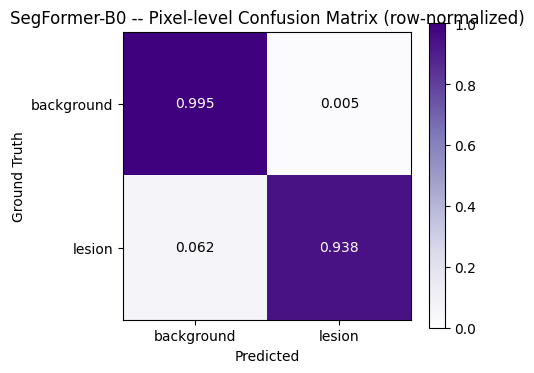

In [14]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap="Purples", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["background", "lesion"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["background", "lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("SegFormer-B0 -- Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i, j] > 0.5 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

Worst-performing test images (lowest per-image IoU):
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00002.jpg: IoU=0.6238
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0007-00001.jpg: IoU=0.6406
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00001.jpg: IoU=0.6928
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00002.jpg: IoU=0.7025
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00003.jpg: IoU=0.7071
  /kaggle/input/datasets/sumaiyahoque/breast-cancer/BCSD-2024/Final Data Set/Final Data Set/P10/left/Orignal Image/IMG-0011-00004.jpg: IoU=0.7119


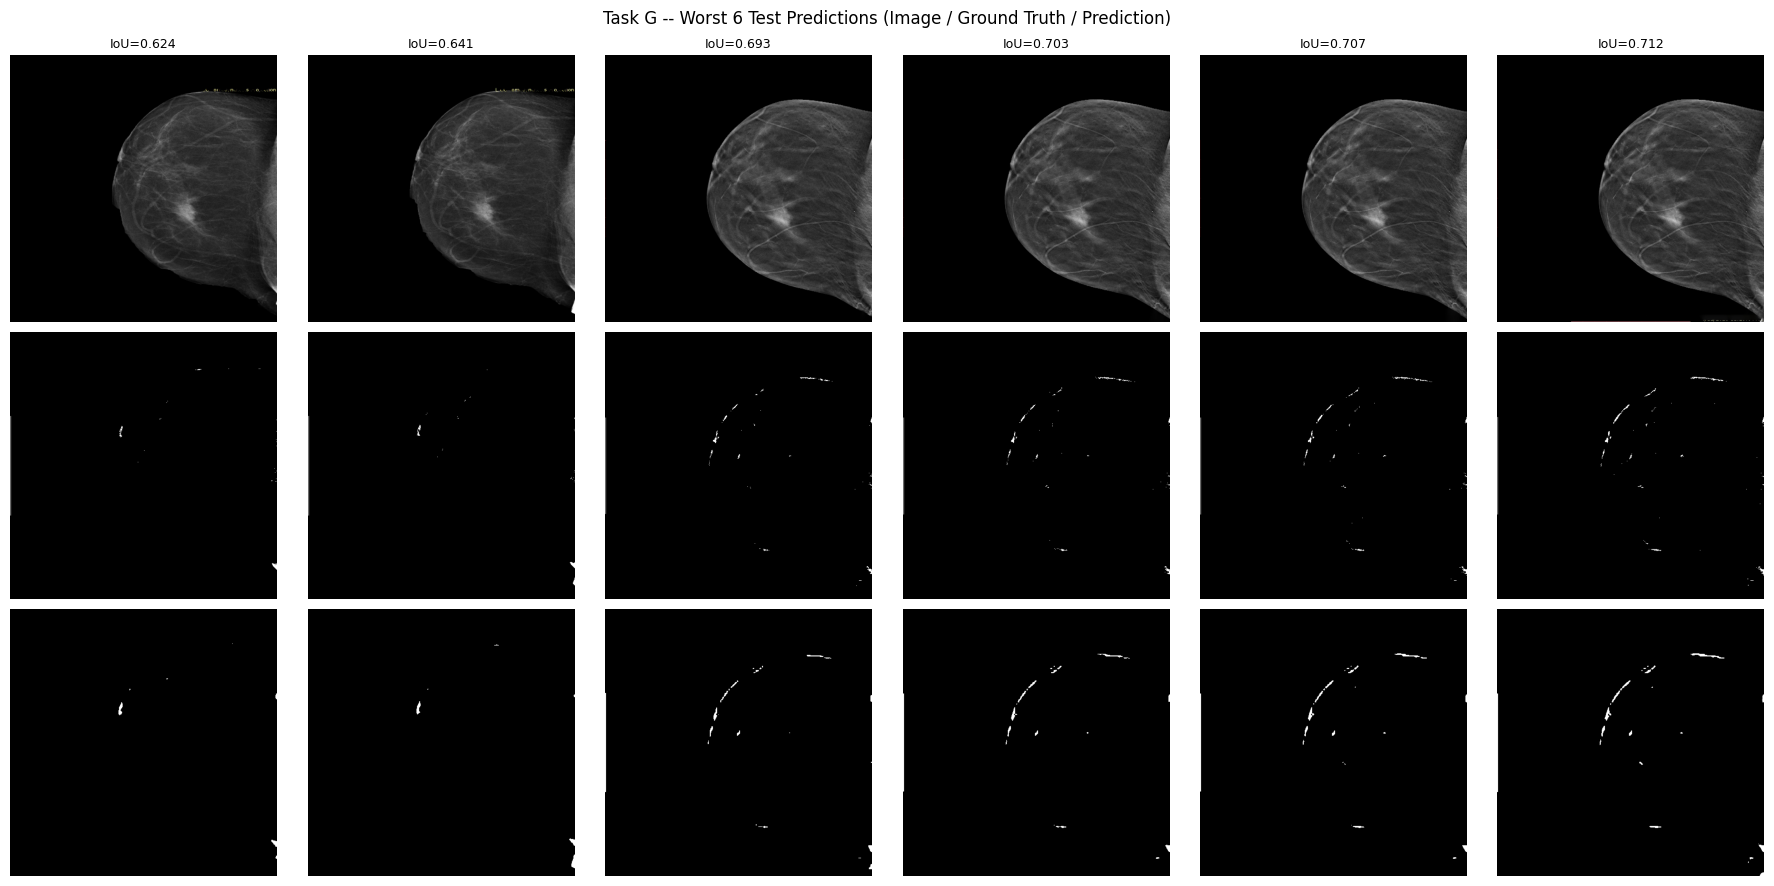

In [15]:
per_image_iou_sorted = sorted(test_results["per_image_iou"], key=lambda x: x[1])
worst_n = 6
worst_cases = per_image_iou_sorted[:worst_n]

print("Worst-performing test images (lowest per-image IoU):")
for path, iou in worst_cases:
    print(f"  {path}: IoU={iou:.4f}")

fig, axes = plt.subplots(3, worst_n, figsize=(3 * worst_n, 9))
for col, (path, iou) in enumerate(worst_cases):
    row = test_ds.df[test_ds.df["img_path"] == path].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    gt_mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask >= MASK_THRESHOLD).astype(np.uint8)

    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gt_resized = cv2.resize(gt_mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    tensor_img = (img_resized.astype(np.float32) / 255.0 - IMG_MEAN) / IMG_STD
    tensor_img = torch.from_numpy(tensor_img.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = forward_upsampled(model, tensor_img).argmax(dim=1).squeeze(0).cpu().numpy()

    axes[0, col].imshow(img_resized); axes[0, col].set_title(f"IoU={iou:.3f}", fontsize=9); axes[0, col].axis("off")
    axes[1, col].imshow(gt_resized, cmap="gray"); axes[1, col].axis("off")
    axes[2, col].imshow(pred, cmap="gray"); axes[2, col].axis("off")

plt.suptitle("Task G -- Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout()
plt.show()

In [17]:
off_diag_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            off_diag_pairs.append(((i, j), cm[i, j]))
off_diag_pairs.sort(key=lambda x: -x[1])

class_names = ["background", "lesion"]
print("Most confused class pairs (ground_truth -> predicted, pixel count):")
for (i, j), count in off_diag_pairs:
    print(f"  {class_names[i]} -> {class_names[j]}: {count:,} pixels")

Most confused class pairs (ground_truth -> predicted, pixel count):
  background -> lesion: 213,870 pixels
  lesion -> background: 55,965 pixels


In [18]:
model_summary = {
    "model_name": "SegFormer-B0",
    "config": TRAIN_CONFIG,
    "actual_epochs_trained": TRAIN_CONFIG["epochs"],  # update if you extended past 50
    "best_epoch": best_epoch,
    "total_train_time_minutes": round(total_train_time / 60, 2),
    "test_metrics": {
        "mIoU": test_results["mIoU"],
        "per_class_iou": test_results["per_class_iou"],
        "overall_pixel_accuracy": test_results["overall_pixel_accuracy"],
        "mean_pixel_accuracy": test_results["mean_pixel_accuracy"],
        "mean_dice": test_results["mean_dice"],
        "dice_per_class": test_results["dice_per_class"],
    },
}

if os.path.exists(CONFIG_PATHS["results_json"]):
    with open(CONFIG_PATHS["results_json"], "r") as f:
        all_results = json.load(f)
else:
    all_results = {}

all_results["SegFormer-B0"] = model_summary

with open(CONFIG_PATHS["results_json"], "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Saved SegFormer-B0 results to {CONFIG_PATHS['results_json']}")
print(json.dumps(model_summary, indent=2))


Saved SegFormer-B0 results to /kaggle/working/results.json
{
  "model_name": "SegFormer-B0",
  "config": {
    "model": "SegFormer-B0 (nvidia/segformer-b0-finetuned-ade-512-512)",
    "num_classes": 2,
    "input_size": 512,
    "batch_size": 8,
    "epochs": 50,
    "optimizer": "AdamW",
    "learning_rate": 6e-05,
    "weight_decay": 0.0001,
    "lr_schedule": "CosineAnnealingLR (T_max=epochs) with 5-epoch linear warmup",
    "loss_function": "Weighted CrossEntropyLoss (+ Dice loss, 0.5 weight each) -- computed manually, NOT the HF built-in loss",
    "class_weights": [
      0.1599999964237213,
      1.840000033378601
    ],
    "seed": 42
  },
  "actual_epochs_trained": 50,
  "best_epoch": 19,
  "total_train_time_minutes": 58.25,
  "test_metrics": {
    "mIoU": 0.8758055116426439,
    "per_class_iou": [
      0.9937531920162074,
      0.7578578312690804
    ],
    "overall_pixel_accuracy": 0.99387298311506,
    "mean_pixel_accuracy": 0.9664466514044168,
    "mean_dice": 0.929559186